In [4]:
from openpiv import tools, pyprocess, validation, filters, scaling, piv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [7]:
img_path = '/Users/josephinelahmani/Desktop/ofmeca_elas/data/elas/experiment_1/T_100.0_E_500.0_nu_0.45/im_00_cell_003_img.npy'

images = np.load(img_path)

In [8]:
frame_a = images[0]
frame_b = images[1]

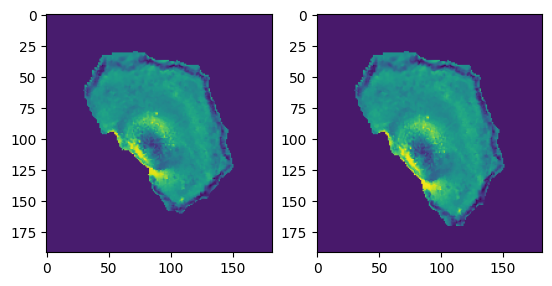

In [125]:
fig, axes = plt.subplots(1, 2)
axes[0].imshow(frame_a)
axes[1].imshow(frame_b)

In [10]:
frame_a_norm = ((frame_a - frame_a.min()) / (frame_a.max() - frame_a.min()) * 255).astype(np.int32)
frame_b_norm = ((frame_b - frame_b.min()) / (frame_b.max() - frame_b.min()) * 255).astype(np.int32)

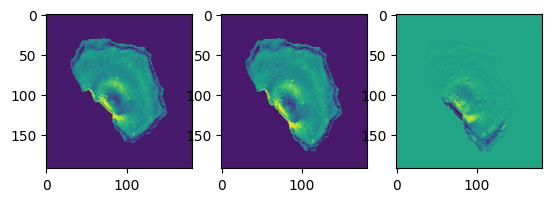

In [127]:
fig, axes = plt.subplots(1, 3)
axes[0].imshow(frame_a_norm)
axes[1].imshow(frame_b_norm)
axes[2].imshow(frame_a_norm - frame_b_norm)

In [38]:
from scipy.interpolate import griddata

def inverse_transform_coordinates(x, y, u, v):
    """Revert physical coordinates back to image coordinates"""
    if y.ndim == 1:
        y = y[::-1]
    else:
        y = y[::-1, :]
    return x, y, u, v

def get_dense_displacement(frame_a, frame_b, window_size=8, overlap=2, 
                           search_area=16, s2n_thresh=1.3, method='cubic'):
    """
    Get pixel-level dense displacement field
    """
    
    x, y, u, v, s2n = piv.simple_piv(
        frame_a, frame_b, 
        window_size=window_size, 
        overlap=overlap,
        search_area_size=search_area, 
        dt=1.0,
        validation_method='sig2noise', 
        plot=False
    )
    
    x, y, u, v = inverse_transform_coordinates(x, y, u, v)
    
    
    valid = s2n > s2n_thresh
    
    flags = validation.sig2noise_val(s2n, threshold=1.2)
    u_filtered, v_filtered = filters.replace_outliers(
        u, v, flags,
        method='localmean',
        max_iter=5,          # ↑ from 3
        kernel_size=5        # ↑ from 3
    )
    x_valid = x[valid]
    y_valid = y[valid]
    u_valid = u_filtered[valid]
    v_valid = v_filtered[valid]
    
    h, w = frame_a.shape
    y_dense, x_dense = np.mgrid[0:h:1, 0:w:1]
    
    u_dense = griddata((x_valid, y_valid), u_valid, (x_dense, y_dense), 
                       method=method, fill_value=0)
    v_dense = griddata((x_valid, y_valid), v_valid, (x_dense, y_dense), 
                       method=method, fill_value=0)
    
    u_dense = np.nan_to_num(u_dense, nan=0.0)
    v_dense = np.nan_to_num(v_dense, nan=0.0)
    
    return u_dense, v_dense, (x, y, u, v, valid, s2n)

In [ ]:
# Get dense field
u_dense, v_dense, sparse_results = get_dense_displacement(
    frame_a_norm, frame_b_norm,
    window_size=16,
    overlap=8,   
    search_area=24, 
    s2n_thresh=1.2,
)

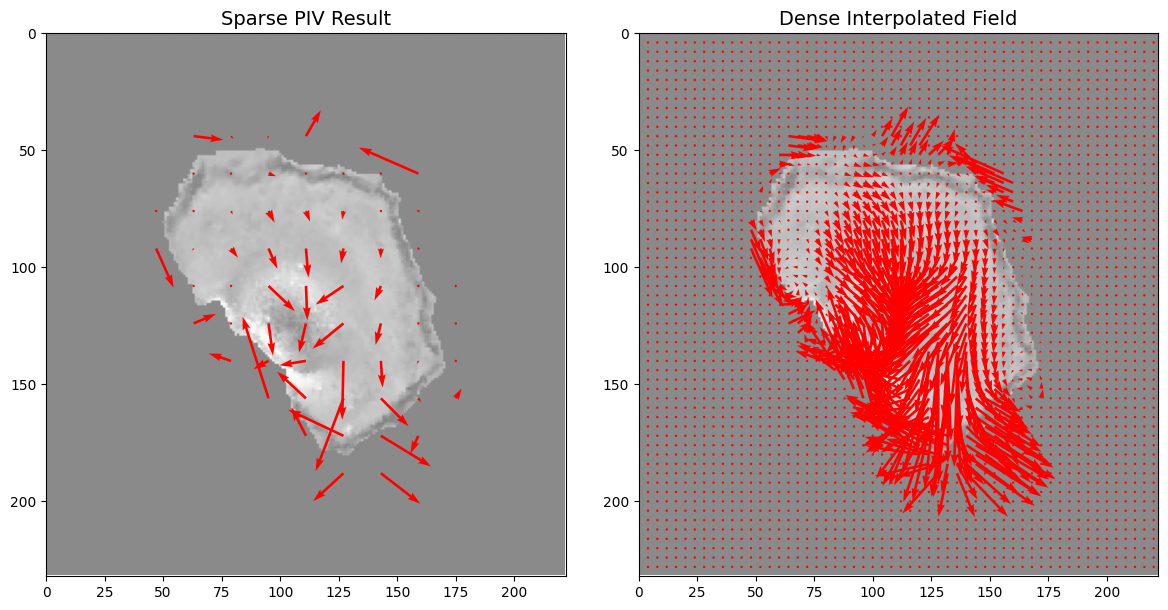

6.76321128726487 11.0


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Sparse PIV
x, y, u, v, valid, s2n = sparse_results

ax = axes[0]
ax.imshow(frame_a_norm, cmap='gray', alpha=0.5, origin='upper')
ax.quiver(x[valid], y[valid], u[valid], v[valid], scale=70, color='r', width=0.005)
ax.set_title('Sparse PIV Result', fontsize=14)
ax.set_xlim(0, frame_a_norm.shape[1])
ax.set_ylim(frame_a_norm.shape[0], 0)

# Dense interpolated
ax = axes[1]
h, w = u_dense.shape
y_dense, x_dense = np.mgrid[0:h:1, 0:w:1]
ax.imshow(frame_a_norm, cmap='gray', alpha=0.5, origin='upper')
skip = 4 
ax.quiver(x_dense[::skip, ::skip], y_dense[::skip, ::skip], 
          u_dense[::skip, ::skip], v_dense[::skip, ::skip], 
          scale=50, color='r', width=0.005)
ax.set_title('Dense Interpolated Field', fontsize=14)
ax.set_xlim(0, w)
ax.set_ylim(h, 0)

plt.tight_layout()
plt.show()

print(u.max(), v.max())

In [ ]:
def pad_to_multiple_8(arr):
    h, w = arr.shape
    
    pad_h = (8 - h % 8) % 8  # 0 si déjà divisible
    pad_w = (8 - w % 8) % 8
    
    arr_padded = np.pad(arr, ((0, pad_h), (0, pad_w)), mode="edge")
    
    return arr_padded, h, w

def unpad_flow(flow_np, orig_h, orig_w):
    return flow_np[:, :orig_h, :orig_w]

In [67]:
from torchvision.models.optical_flow import Raft_Large_Weights, raft_large
import torch

frame_a_padded, h, w = pad_to_multiple_8(frame_a)
frame_b_padded, h, w = pad_to_multiple_8(frame_b)

# frame_a shape: (H, W) -> need (1, C, H, W)
img1 = torch.from_numpy(frame_a_padded).unsqueeze(0).unsqueeze(0)  # (1, C, H, W)
img2 = torch.from_numpy(frame_b_padded).unsqueeze(0).unsqueeze(0)  # (1, C, H, W)

img1 = img1.repeat(1, 3, 1, 1)  # (1, 3, H, W)
img2 = img2.repeat(1, 3, 1, 1)  # (1, 3, H, W)

weights = Raft_Large_Weights.DEFAULT
transforms = weights.transforms()

device = "cuda" if torch.cuda.is_available() else "cpu"

model = raft_large(weights=Raft_Large_Weights.DEFAULT, progress=False).to(device)
model = model.eval()

img1, img2 = transforms(img1, img2)

img1 = img1.to(device)
img2 = img2.to(device)

with torch.no_grad():
    list_of_flows = model(img1, img2)

predicted_flow = list_of_flows[-1]
print(predicted_flow.shape)

torch.Size([1, 2, 232, 224])


In [ ]:
def raft_algo(img: np.ndarray) -> np.ndarray:
    
    def pad_to_multiple_8(arr):
        h, w = arr.shape
        
        pad_h = (8 - h % 8) % 8
        pad_w = (8 - w % 8) % 8
        
        arr_padded = np.pad(arr, ((0, pad_h), (0, pad_w)), mode="edge")
        
        return arr_padded, h, w

    def unpad_flow(flow_np, orig_h, orig_w):
        return flow_np[:, :orig_h, :orig_w]

    frame_1_padded, h, w = pad_to_multiple_8(img[0])
    frame_2_padded, _, _ = pad_to_multiple_8(img[1])

    # frame_1 shape: (H, W) -> need (1, C, H, W)
    img1 = torch.from_numpy(frame_1_padded).unsqueeze(0).unsqueeze(0)  # (1, C, H, W)
    img2 = torch.from_numpy(frame_2_padded).unsqueeze(0).unsqueeze(0)  # (1, C, H, W)

    img1 = img1.repeat(1, 3, 1, 1)  # (1, 3, H, W)
    img2 = img2.repeat(1, 3, 1, 1)  # (1, 3, H, W)

    weights = Raft_Large_Weights.DEFAULT
    transforms = weights.transforms()

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = raft_large(weights=Raft_Large_Weights.DEFAULT, progress=False).to(device)
    model = model.eval()

    img1, img2 = transforms(img1, img2)

    img1 = img1.to(device)
    img2 = img2.to(device)

    with torch.no_grad():
        list_of_flows = model(img1, img2)

    predicted_flow = list_of_flows[-1]
    predicted_flow_np = predicted_flow.cpu().numpy()
    flow_np = np.transpose(unpad_flow(predicted_flow_np, h, w), (1, 0, 2, 3))
    
    return flow_np

In [74]:
predicted_flow_np = predicted_flow.cpu().numpy()
flow_np = unpad_flow(predicted_flow_np, h, w)

flow_np = np.transpose(flow_np, (1, 0, 2, 3))

In [75]:
flow_np.shape

(2, 1, 222, 224)

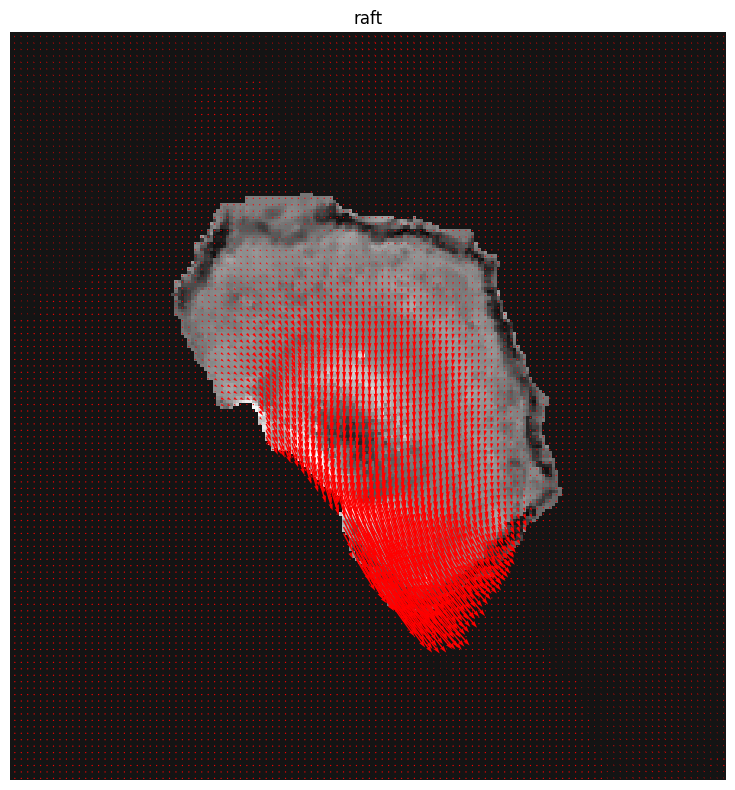

In [70]:
def plot_flow_quiver(frame, flow_np, step=16):
    """
    Affiche le flux optique sous forme de quivers sur l'image frame.
    
    Args:
        frame    : numpy array (H, W) - image de référence
        flow_np  : numpy array (2, H, W) - flux optique (u, v)
        step     : int - espacement entre les flèches (plus grand = moins de flèches)
    """
    h, w = frame.shape

    flow_u = flow_np[0]
    flow_v = flow_np[1]

    y, x = np.mgrid[step//2:h:step, step//2:w:step]

    u = flow_u[y, x]
    v = flow_v[y, x]

    fig, ax = plt.subplots(figsize=(10, 8))

    ax.imshow(frame, cmap="gray")
    ax.quiver(
        x, y, u, v,
        color="red",
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.002,
    )

    ax.set_title("raft")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


plot_flow_quiver(frame_a, flow_np, step=2)